# ESM-2 Tutorial: Embeddings and Fine-Tuning on GFP

**ESM-2** (Evolutionary Scale Modeling 2) is a protein language model from Meta AI, pre-trained on hundreds of millions of protein sequences. This notebook shows you how to:

1. Load ESM-2 as a frozen embedding extractor
2. Extract per-sequence embeddings for GFP (Green Fluorescent Protein) variants
3. Visualise the embedding space with UMAP, coloured by fluorescence
4. Fine-tune ESM-2 with **Masked Language Modelling (MLM)**
5. Fine-tune ESM-2 with **log-likelihood** and compare the two objectives
6. Use `predict()` on a fine-tuned model

**Prerequisites:** install the `tutorials` dependency group before running:
```bash
uv sync --group tutorials
```

**Expected runtime:** < 5 minutes on CPU using `facebook/esm2_t6_8M_UR50D` (8M parameters, ~31 MB download on first run).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import umap

from alf_core import LabelledCandidates, Modality
from alf_core import BaseDatasetConfig
from alf_tools.datasets.gfp import GFP
from alf_tools.models.esm2 import ESM2Model, ESM2ModelConfig, ESM2TrainConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

/Users/o.gallup/Code/alf/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 1. Load the GFP Dataset

**Green Fluorescent Protein (GFP)** is a classic protein engineering benchmark. The dataset contains ~1 000 nucleotide sequences encoding GFP variants, each labelled with `medianBrightness` — a proxy for how well the variant fluoresces.

`GFP.load_dataset()` downloads and caches the CSV on first call, then returns a `LabelledCandidates` object where each `Candidate.data` is a nucleotide sequence string and `.labels` is a `numpy` array of brightness scores.

We use 50 sequences for embedding and fine-tuning to keep CPU runtime under 5 minutes.

In [2]:
gfp_config = BaseDatasetConfig(
    name="gfp",
    modality=Modality.SEQUENCE,
    seed=42,
    train_ratio=0.8,
    test_ratio=0.1,
    validation_frac=0.1,
)
gfp = GFP(gfp_config)
data: LabelledCandidates = gfp.load_dataset()

print(f"Total sequences : {len(data.candidates)}")
print(f"Example sequence: {data.candidates[0].data[:40]}...")
print(f"Brightness range: {data.labels.min():.2f} – {data.labels.max():.2f}")

Total sequences : 1000
Example sequence: AGCAAGGGCGAGGAGCTGTTCACCGGGGTGGTGCCCATCC...
Brightness range: 1.29 – 4.03


In [3]:
embed_candidates    = data.candidates[:50]
embed_labels        = data.labels[:50]        # numpy array, shape (50,)

finetune_candidates = data.candidates[:50]
finetune_labels     = data.labels[:50]        # numpy array, shape (50,)

## 2. Initialise ESM-2 as a Frozen Embedding Extractor

**`ESM2ModelConfig`** controls the architecture:
- `model_id` — any `facebook/esm2_*` HuggingFace checkpoint
- `pooling` — how to collapse per-token hidden states to one vector: `"mean"` (average over non-padding positions), `"cls"` (first token), or `"last_hidden_state"` (full sequence tensor)
- `repr_layer` — which transformer layer to read; `-1` is the final layer

**`ESM2TrainConfig(freeze_backbone=True)`** makes `train()` a no-op: weights are never updated. This gives us a pure feature extractor that runs in inference mode only.

> **Contributors:** `ESM2Model.predict()` in `tools/alf_tools/models/esm2.py` tokenizes via `featurise()`, runs a forward pass with `output_hidden_states=True`, then pools the selected hidden layer.

In [4]:
model_cfg = ESM2ModelConfig(
    model_id="facebook/esm2_t6_8M_UR50D",
    pooling="mean",
    repr_layer=-1,
)
train_cfg = ESM2TrainConfig(freeze_backbone=True)

model = ESM2Model(name="esm2-gfp", model_config=model_cfg, train_config=train_cfg, device=device)
print(model)

## 3. Extract Sequence Embeddings

`predict()` runs a batched forward pass and returns a `Predictions` object. `predictions.means` is a `(N, hidden_dim)` numpy array — one 320-dimensional vector per sequence.

Note: `featurise()` only tokenizes (returns `{"input_ids", "attention_mask"}`); the forward pass and pooling live entirely in `predict()`.

In [5]:
predictions_frozen = model.predict(embed_candidates)
X = predictions_frozen.means  # shape (50, 320) — already numpy
print(f"Embedding shape: {X.shape}")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Embedding shape: (50, 320)


## 4. UMAP of Frozen Embeddings

We project 320-dimensional embeddings to 2D with UMAP and colour each point by fluorescence. If ESM-2 has captured meaningful structure in GFP sequence space, high-brightness variants should cluster rather than scatter uniformly.

/Users/o.gallup/Code/alf/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


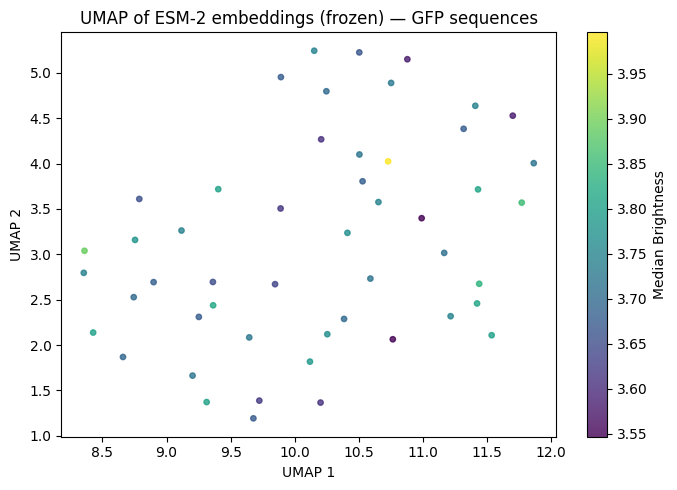

In [6]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
coords  = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=embed_labels, cmap="viridis", s=15, alpha=0.8)
plt.colorbar(sc, ax=ax, label="Median Brightness")
ax.set_title("UMAP of ESM-2 embeddings (frozen) — GFP sequences")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

## 5. Fine-Tune with Masked Language Modelling (MLM)

MLM is the same objective ESM-2 was pre-trained with: randomly mask 15% of sequence tokens (never special tokens like `[CLS]` / `[EOS]`), then train the model to predict the originals. Fine-tuning on GFP sequences nudges representations toward this protein family.

Masked tokens are handled with an 80 / 10 / 10 split:
- 80% replaced with `[MASK]`
- 10% replaced with a random vocabulary token
- 10% left unchanged (still counted in the loss)

> **Contributors:** masking logic is in `ESM2Model._mask_tokens()` in `tools/alf_tools/models/esm2.py`.

We use 40 train / 10 val sequences and 2 epochs — enough to see the loss move on CPU in under 2 minutes.

In [7]:
n_train    = 40
train_data = LabelledCandidates(
    candidates=finetune_candidates[:n_train],
    labels=finetune_labels[:n_train],
)
val_data = LabelledCandidates(
    candidates=finetune_candidates[n_train:],
    labels=finetune_labels[n_train:],
)

In [8]:
train_cfg_mlm = ESM2TrainConfig(
    freeze_backbone=False,
    loss_type="mlm",
    num_epochs=2,
    batch_size=4,
    learning_rate=1e-4,
    mask_probability=0.15,
)
model_mlm = ESM2Model(name="esm2-gfp-mlm", model_config=model_cfg, train_config=train_cfg_mlm, device=device)
model_mlm.train(train_data, val_data)

metrics_mlm = model_mlm.get_training_summary_metrics()
print("MLM summary metrics:", metrics_mlm)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


MLM summary metrics: {'final_train_loss': 1.1701165199279786, 'final_train_perplexity': 3.2223680867518643, 'final_train_token_accuracy': 0.4783203899860382, 'final_val_loss': 1.1248797575632732, 'final_val_perplexity': 3.079846498404841, 'final_val_token_accuracy': 0.49863263964653015}


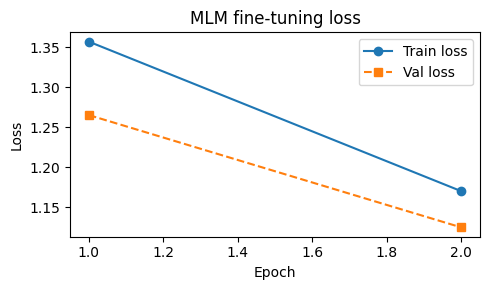

In [9]:
epoch_metrics = model_mlm.get_epoch_metrics()
train_losses  = [m.train_loss for m in epoch_metrics]
epochs        = list(range(1, len(train_losses) + 1))
val_points    = [(m.epoch + 1, m.val_loss) for m in epoch_metrics if m.val_loss is not None]

plt.figure(figsize=(5, 3))
plt.plot(epochs, train_losses, marker="o", label="Train loss")
if val_points:
    vx, vy = zip(*val_points)
    plt.plot(vx, vy, marker="s", linestyle="--", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLM fine-tuning loss")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Fine-Tune with Log-Likelihood

The log-likelihood objective differs from MLM in one key way: **all** non-special tokens are masked simultaneously. The model must reconstruct the full sequence at once, approximating its pseudo-log-likelihood (PLL) — a stricter signal that is closer to how ESM-2 fitness scores are typically computed.

The only config change vs. MLM is `loss_type="log_likelihood"`. Because all positions are masked, losses will typically be higher than MLM.

> **Contributors:** masking logic is in `ESM2Model._compute_log_likelihood_labels()` in `tools/alf_tools/models/esm2.py`.

In [10]:
train_cfg_ll = ESM2TrainConfig(
    freeze_backbone=False,
    loss_type="log_likelihood",
    num_epochs=2,
    batch_size=4,
    learning_rate=1e-4,
)
model_ll = ESM2Model(name="esm2-gfp-ll", model_config=model_cfg, train_config=train_cfg_ll, device=device)
model_ll.train(train_data, val_data)

metrics_ll = model_ll.get_training_summary_metrics()
print("Log-likelihood summary metrics:", metrics_ll)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Log-likelihood summary metrics: {'final_train_loss': 1.3577370285987853, 'final_train_perplexity': 3.887386296538579, 'final_train_token_accuracy': 0.33588936924934387, 'final_train_log_likelihood': -1.3577370285987853, 'final_val_loss': 1.343623439470927, 'final_val_perplexity': 3.8329066793629667, 'final_val_token_accuracy': 0.3518207371234894, 'final_val_log_likelihood': -1.343623439470927}


In [11]:
comparison = pd.DataFrame(
    {"MLM": metrics_mlm, "Log-likelihood": metrics_ll}
).T
display(comparison)

,final_train_loss,final_train_perplexity,final_train_token_accuracy,final_val_loss,final_val_perplexity,final_val_token_accuracy,final_train_log_likelihood,final_val_log_likelihood
MLM,1.170117,3.222368,0.478320,1.124880,3.079846,0.498633,NaN,NaN
Log-likelihood,1.357737,3.887386,0.335889,1.343623,3.832907,0.351821,-1.357737,-1.343623


## 7. Predict with a Fine-Tuned Model

After fine-tuning, `predict()` returns embeddings from the adapted model — `predictions.means` is still a `(N, hidden_dim)` numpy array, now reflecting the GFP-adapted representations. These can be fed directly into an ALF active learning loop as surrogate model features.

(`predictions.variances` is `None` for ESM-2, since the model does not produce uncertainty estimates.)

In [12]:
test_candidates = data.candidates[200:210]
predictions = model_mlm.predict(test_candidates)

print(f"Embedding shape      : {predictions.means.shape}")        # (10, 320)
print(f"First 5 dims (seq 0) : {predictions.means[0, :5]}")
print(f"Variances            : {predictions.variances}")           # None

Embedding shape      : (10, 320)
First 5 dims (seq 0) : [ 0.04284135  0.08548358 -0.88415116  0.0372757   0.12493617]
Variances            : None
